# Chapter 6: Polygonal Chains

**Source Span.** `Discrete and Computational Geometry, 2nd Edition.pdf`, Chapter 6, printed pages 170-198 (PDF pages 185-213).

**Chapter goal.** Study polygonal chains as moving geometric constraints: fixed link lengths define configuration spaces, Cauchy's arm lemma predicts how endpoint distance changes when angles open, reachability is governed by length intervals, folding can become computationally hard, planar chains can be straightened, spatial chains can lock, and shortening flows simplify curves.

The notebook uses visible code experiments and original diagrams to capture the chapter without copying textbook prose or figures.


## Computational Translation Guide

| Chapter idea | Computational representation | Inspection target |
| --- | --- | --- |
| Cauchy's arm lemma | two-chain angle sweep | endpoint distance increases with the included angle |
| chain configuration | joint-angle grid and reachable endpoint cloud | configuration space is made of angle choices, not free endpoints |
| reachability | annulus/interval from link lengths | target distance lies between lower and upper radius |
| folding decision | signed length ledger | a proposed folded state is easy to verify even if hard to find |
| straightening | angle interpolation with fixed lengths | link lengths stay fixed while endpoint distance grows |
| locked 3D chains | schematic spatial linkage | planar theorem does not transfer to all spatial chains |
| curve shortening | iterative midpoint smoothing | total length decreases monotonically |


## Visual Storyboard

1. **Arm lemma sweep.** Draw two-link configurations and plot endpoint distance as the opening angle changes.
2. **Reachability annulus.** Sample a three-link arm and compare the cloud with the exact radial interval.
3. **Folding verification ledger.** Enumerate sign choices for a collinear chain and distinguish verification from search.
4. **Straightening and locking board.** Show planar straightening snapshots and a 3D locked-chain warning schematic.
5. **Curve-shortening flow.** Iterate a polygonal curve-shortening rule and check length decrease.


In [1]:
from pathlib import Path
import sys, json, math, itertools
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from IPython.display import display, Markdown

BOOK_ROOT = next(candidate for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate/'AGENTS.md').exists() and (candidate/'source_map.json').exists())
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))
from utils.artifacts import chapter_artifact_root, save_json, save_csv, save_matplotlib, assert_artifacts, display_artifact

UNIT_KEY='chapter-06-polygonal-chains'
ARTIFACT_ROOT=chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES, TABLES, CHECKS = ARTIFACT_ROOT/'figures', ARTIFACT_ROOT/'tables', ARTIFACT_ROOT/'checks'
artifact_paths=[]
plt.rcParams.update({'figure.figsize':(7,5), 'axes.grid':True})


## Source Coverage And Library Routing

Polygonal chains are finite metric objects, so NumPy and Matplotlib are the right primary tools: they keep lengths, angles, endpoints, and shortening visible. The chapter's complexity discussion is represented by an explicit verification ledger rather than by a black-box solver. The 3D warning is schematic because the point is conceptual: Carpenter's Rule is planar, while spatial chains can lock.


In [2]:
source_coverage={
    'Cauchy arm lemma': True,
    'chain configurations and degrees of freedom': True,
    'robot arm reachability': True,
    'folding and NP-complete sign-style decisions': True,
    'planar straightening and Carpenter rule': True,
    'locked chains in 3D': True,
    'curve shortening': True,
    'discrete curve shortening': True,
}
library_rows=[
    {'concept':'arm lemma', 'representation':'angle sweep and endpoint distance plot', 'library':'NumPy + Matplotlib', 'check':'distance monotone'},
    {'concept':'configuration/reachability', 'representation':'joint-angle endpoint cloud and annulus', 'library':'NumPy + Matplotlib', 'check':'radii inside interval'},
    {'concept':'folding verification', 'representation':'signed length table', 'library':'CSV/JSON', 'check':'candidate sums verified'},
    {'concept':'curve shortening', 'representation':'iterated polygon path', 'library':'NumPy + Matplotlib', 'check':'perimeter decreases'},
]
source_coverage_path=save_json({'source_span':'printed pages 170-198, PDF pages 185-213', 'coverage':source_coverage}, CHECKS/'source-coverage.json')
library_table=save_csv(library_rows, TABLES/'library-routing.csv')
artifact_paths.extend([source_coverage_path, library_table])


## 1. Cauchy's Arm Lemma As A Distance Plot

For a two-link arm with fixed link lengths, the endpoint distance is determined by the included angle. Opening the angle increases the distance between the endpoints. The chapter uses this principle as a local comparison tool for more complicated chains; here the finite sweep makes the monotonicity visible and checkable.


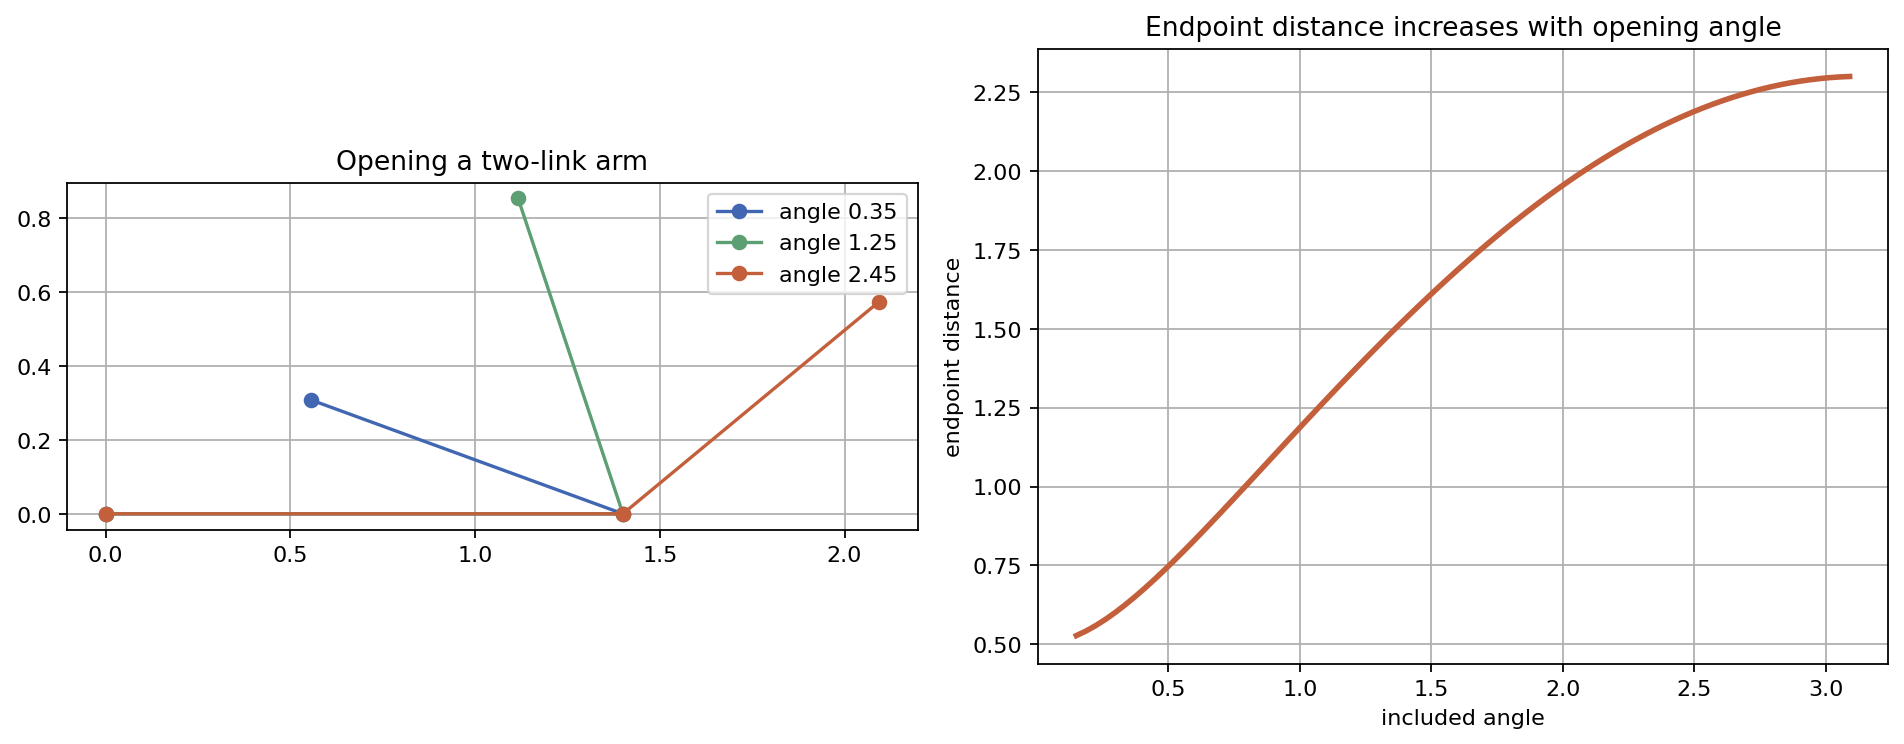

In [3]:
L1,L2=1.4,0.9
angles=np.linspace(0.15, math.pi-0.05, 80)
distances=np.sqrt(L1**2 + L2**2 - 2*L1*L2*np.cos(angles))
fig,axes=plt.subplots(1,2,figsize=(12,4.8))
for theta,color in zip([0.35,1.25,2.45], ['#4267b2','#5c9f73','#c45f3c']):
    pts=np.array([[0,0],[L1,0],[L1-L2*math.cos(theta), L2*math.sin(theta)]])
    axes[0].plot(pts[:,0],pts[:,1],'-o',color=color,label=f'angle {theta:.2f}')
axes[0].set_aspect('equal'); axes[0].set_title('Opening a two-link arm'); axes[0].legend()
axes[1].plot(angles, distances, color='#c45f3c', linewidth=2.5)
axes[1].set_xlabel('included angle'); axes[1].set_ylabel('endpoint distance')
axes[1].set_title('Endpoint distance increases with opening angle')
fig.tight_layout()
arm_plot=save_matplotlib(fig, FIGURES/'cauchy-arm-distance-sweep.png')
plt.close(fig)
arm_check=save_json({'link_lengths':[L1,L2], 'distance_monotone':bool(np.all(np.diff(distances)>0)), 'min_distance':float(distances.min()), 'max_distance':float(distances.max())}, CHECKS/'cauchy-arm-lemma-checks.json')
artifact_paths.extend([arm_plot, arm_check])
display_artifact(arm_plot, width=900)


## 2. Configuration Space And Reachability

A chain configuration is a choice of joint angles modulo rigid motion. For a planar three-link arm, the endpoint can fill an annular region. The outer radius is the sum of link lengths; the inner radius is the longest link minus the sum of the others if that difference is positive, otherwise zero. This is the computational form of the chapter's reachability criterion.


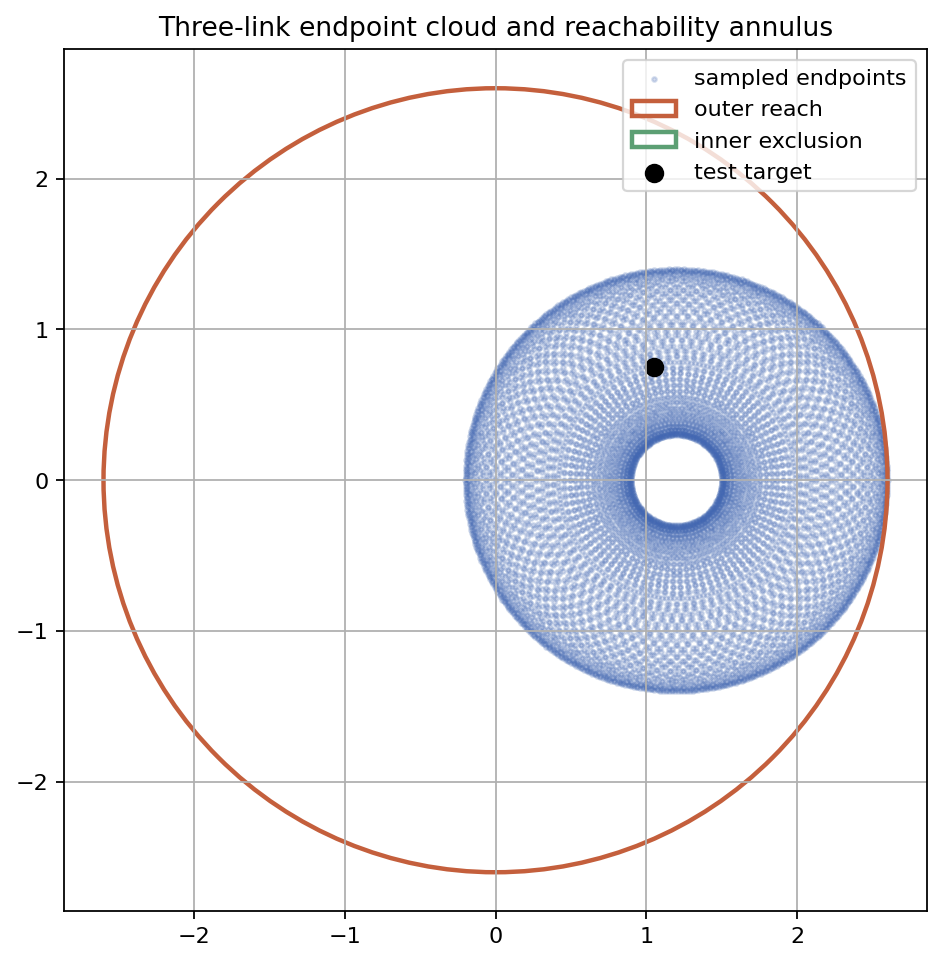

In [4]:
lengths=np.array([1.2,0.85,0.55])
angle_grid=np.linspace(0,2*np.pi,90,endpoint=False)
endpoints=[]
for a,b in itertools.product(angle_grid, repeat=2):
    dirs=np.array([0, a, a+b])
    endpoint=np.sum(np.c_[lengths*np.cos(dirs), lengths*np.sin(dirs)], axis=0)
    endpoints.append(endpoint)
endpoints=np.array(endpoints)
radii=np.linalg.norm(endpoints, axis=1)
outer=float(lengths.sum())
inner=float(max(0, lengths.max() - (lengths.sum()-lengths.max())))

target=np.array([1.05,0.75]); target_radius=float(np.linalg.norm(target))
fig,ax=plt.subplots(figsize=(7,7))
ax.scatter(endpoints[:,0],endpoints[:,1],s=4,color='#4267b2',alpha=0.22,label='sampled endpoints')
ax.add_patch(Circle((0,0), outer, fill=False, edgecolor='#c45f3c', linewidth=2, label='outer reach'))
ax.add_patch(Circle((0,0), inner, fill=False, edgecolor='#5c9f73', linewidth=2, label='inner exclusion'))
ax.scatter([target[0]],[target[1]],color='black',s=60,label='test target')
ax.set_aspect('equal'); ax.set_title('Three-link endpoint cloud and reachability annulus'); ax.legend()
reach_plot=save_matplotlib(fig, FIGURES/'chain-reachability-annulus.png')
plt.close(fig)
reach_check=save_json({'lengths':lengths.tolist(), 'inner_radius':inner, 'outer_radius':outer, 'sampled_radii_within_interval':bool(radii.min()>=inner-1e-9 and radii.max()<=outer+1e-9), 'target_radius':target_radius, 'target_reachable_by_interval':bool(inner <= target_radius <= outer)}, CHECKS/'reachability-annulus-checks.json')
artifact_paths.extend([reach_plot, reach_check])
display_artifact(reach_plot, width=760)


## 3. Folding Verification Versus Search

The chapter's complexity discussion separates finding a fold from verifying a proposed fold. In a collinear simplification, a proposed sign assignment is easy to check: sum signed lengths and compare with the target. The hard part is discovering a successful assignment among exponentially many candidates, which is why reductions from partition-style problems matter.


In [5]:
fold_lengths=np.array([0.9,1.1,1.7,2.0,2.4])
target_length=0.7
rows=[]
for signs in itertools.product([-1,1], repeat=len(fold_lengths)):
    signed=float(np.dot(signs, fold_lengths))
    rows.append({'signs':' '.join('+' if s>0 else '-' for s in signs), 'signed_sum':signed, 'absolute_endpoint':abs(signed), 'meets_target':abs(abs(signed)-target_length)<1e-9})
solutions=[r for r in rows if r['meets_target']]
fold_table=save_csv(rows, TABLES/'folding-sign-verification-ledger.csv')
fold_check=save_json({'link_count':len(fold_lengths), 'candidate_count':len(rows), 'solution_count':len(solutions), 'verification_is_linear_after_candidate_given':True}, CHECKS/'folding-verification-checks.json')
artifact_paths.extend([fold_table, fold_check])
display(Markdown(f'Folding verification ledger: `{fold_table.relative_to(BOOK_ROOT)}`; candidates checked: {len(rows)}.'))


Folding verification ledger: `artifacts\chapter-06-polygonal-chains\tables\folding-sign-verification-ledger.csv`; candidates checked: 32.

## 4. Straightening In The Plane And A 3D Locking Warning

Carpenter's Rule says a simple open planar chain can be straightened without crossing itself. The snapshots interpolate joint angles toward zero while preserving every link length. The 3D panel is deliberately a warning rather than a theorem proof: spatial chains have room to weave through each other and can become locked, so the planar statement should not be overgeneralized.


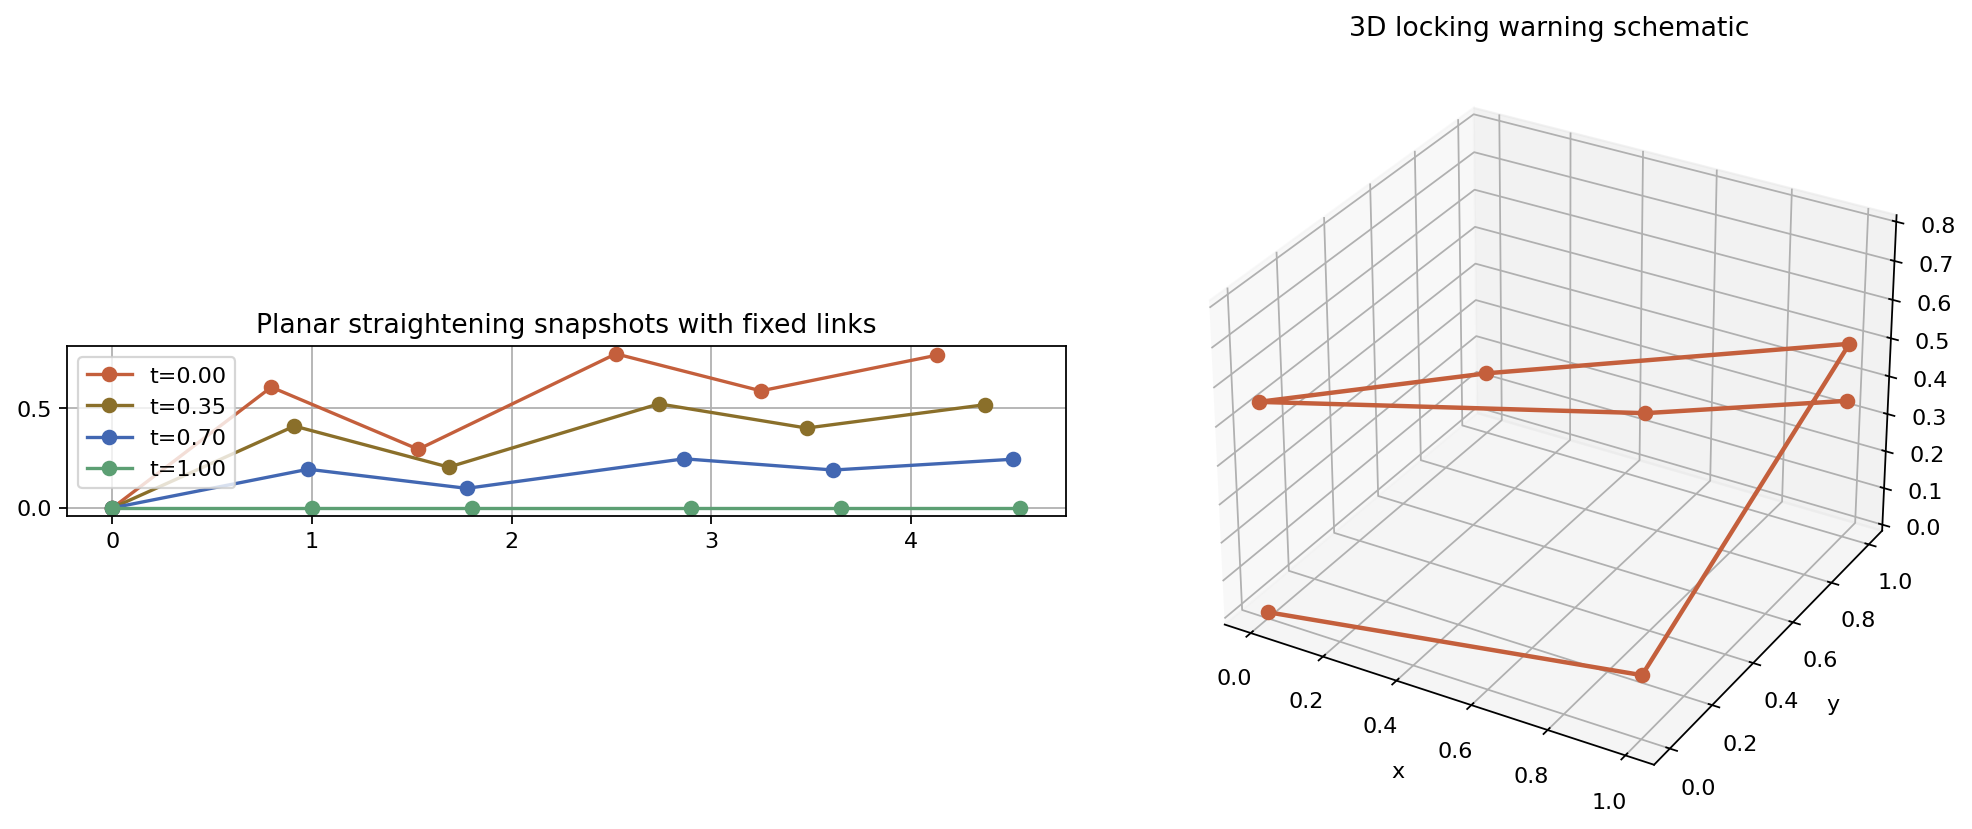

In [6]:
def chain_points(lengths, angles):
    dirs=np.cumsum(angles)
    pts=[np.array([0.0,0.0])]
    for L,ang in zip(lengths, dirs):
        pts.append(pts[-1] + L*np.array([math.cos(ang), math.sin(ang)]))
    return np.array(pts)
straight_lengths=np.array([1.0,0.8,1.1,0.75,0.9])
initial_angles=np.array([0.65,-1.05,0.85,-0.7,0.45])
fig=plt.figure(figsize=(13,5.3))
ax=fig.add_subplot(1,2,1)
per_snapshot_lengths=[]
for t,color in zip([0,0.35,0.7,1.0], ['#c45f3c','#8a6f2a','#4267b2','#5c9f73']):
    pts=chain_points(straight_lengths, (1-t)*initial_angles)
    per_snapshot_lengths.append(np.linalg.norm(np.diff(pts,axis=0),axis=1))
    ax.plot(pts[:,0],pts[:,1],'-o',color=color,label=f't={t:.2f}')
ax.set_aspect('equal'); ax.set_title('Planar straightening snapshots with fixed links'); ax.legend()

ax3=fig.add_subplot(1,2,2,projection='3d')
locked=np.array([[0,0,0],[1,0,0.15],[1,1,0.5],[0,1,0.15],[0,0,0.55],[1,0,0.8],[1,1,0.35]])
ax3.plot(locked[:,0],locked[:,1],locked[:,2],'-o',color='#c45f3c',linewidth=2)
ax3.set_title('3D locking warning schematic')
ax3.set_xlabel('x'); ax3.set_ylabel('y'); ax3.set_zlabel('z')
fig.tight_layout()
straight_plot=save_matplotlib(fig, FIGURES/'straightening-and-3d-locking-warning.png')
plt.close(fig)
lengths_preserved=all(np.allclose(v, straight_lengths) for v in per_snapshot_lengths)
straight_check=save_json({'straightening_snapshots':4, 'link_lengths_preserved':bool(lengths_preserved), 'three_dimensional_locking_warning_recorded':True}, CHECKS/'straightening-locking-checks.json')
artifact_paths.extend([straight_plot, straight_check])
display_artifact(straight_plot, width=900)


## 5. Discrete Curve Shortening

Curve shortening replaces a complicated polygonal curve by simpler curves with smaller total length. The midpoint-style iteration below is a finite analog: each vertex moves toward the average of its neighbors, and the perimeter decreases. This does not prove the continuous theorem, but it gives a reproducible invariant tracker for the chapter's shortening theme.


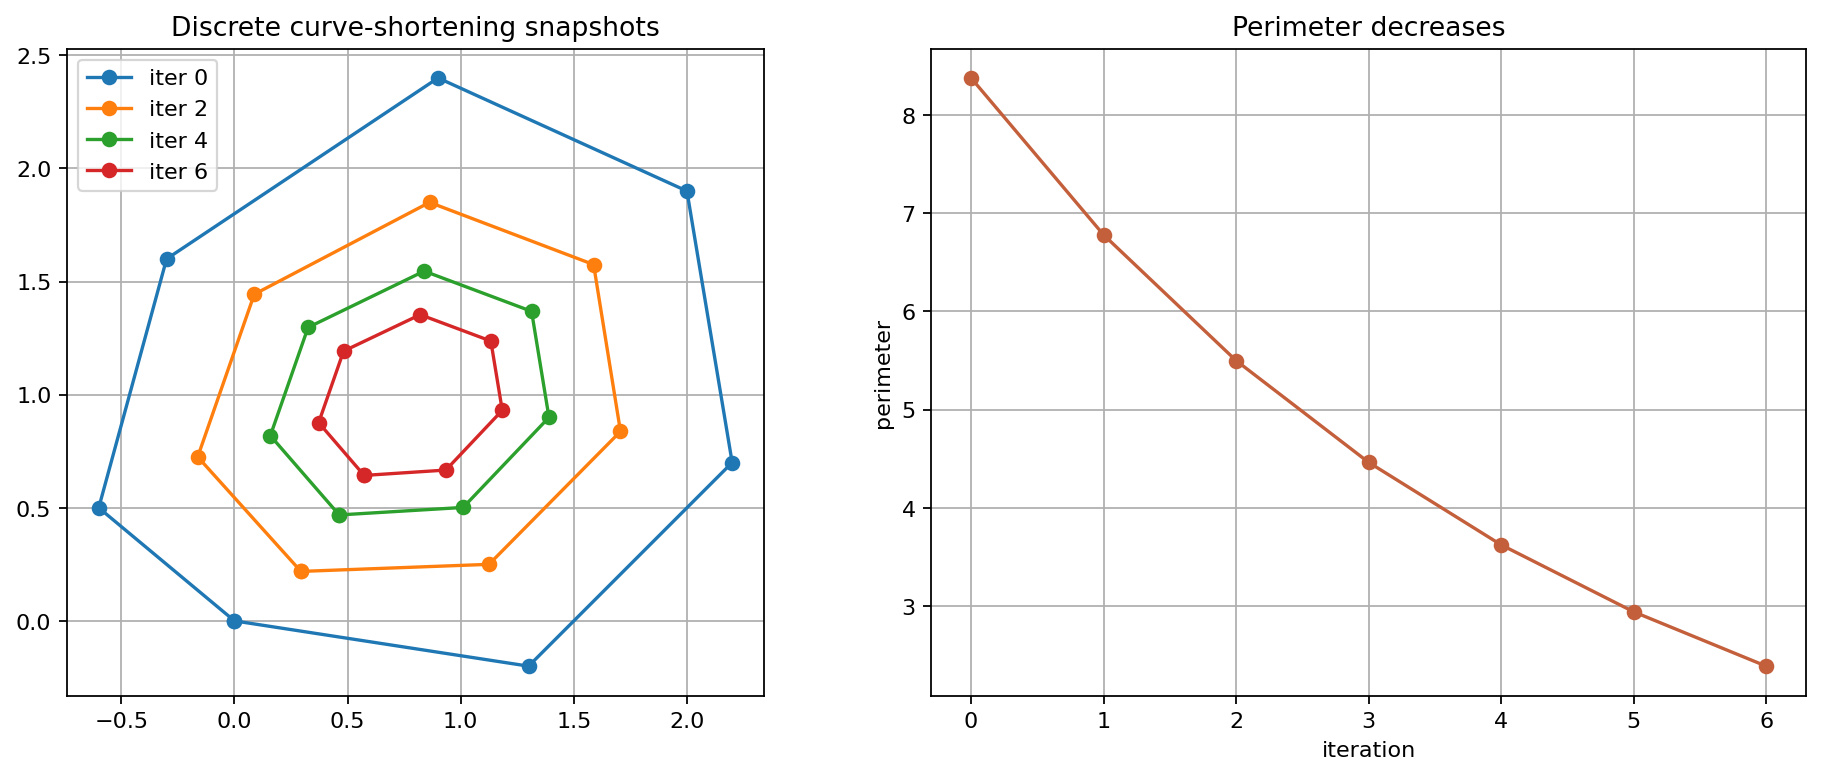

In [7]:
def perimeter(poly):
    return float(np.sum(np.linalg.norm(np.roll(poly,-1,axis=0)-poly,axis=1)))
curve=np.array([[0,0],[1.3,-0.2],[2.2,0.7],[2.0,1.9],[0.9,2.4],[-0.3,1.6],[-0.6,0.5]], dtype=float)
curves=[curve]
for _ in range(6):
    current=curves[-1]
    curves.append(0.5*current + 0.25*np.roll(current,1,axis=0) + 0.25*np.roll(current,-1,axis=0))
perimeters=[perimeter(c) for c in curves]
fig,axes=plt.subplots(1,2,figsize=(12,5))
for i,c in enumerate(curves[::2]):
    axes[0].plot(np.r_[c[:,0],c[0,0]], np.r_[c[:,1],c[0,1]], '-o', label=f'iter {2*i}')
axes[0].set_aspect('equal'); axes[0].set_title('Discrete curve-shortening snapshots'); axes[0].legend()
axes[1].plot(range(len(perimeters)), perimeters, '-o', color='#c45f3c')
axes[1].set_xlabel('iteration'); axes[1].set_ylabel('perimeter'); axes[1].set_title('Perimeter decreases')
fig.tight_layout()
shortening_plot=save_matplotlib(fig, FIGURES/'discrete-curve-shortening-flow.png')
plt.close(fig)
shortening_table=save_csv([{'iteration':i,'perimeter':p} for i,p in enumerate(perimeters)], TABLES/'curve-shortening-perimeter-ledger.csv')
shortening_check=save_json({'iterations':len(perimeters)-1, 'perimeter_monotone_decreasing':bool(all(perimeters[i+1] <= perimeters[i]+1e-12 for i in range(len(perimeters)-1))), 'initial_perimeter':perimeters[0], 'final_perimeter':perimeters[-1]}, CHECKS/'curve-shortening-checks.json')
artifact_paths.extend([shortening_plot, shortening_table, shortening_check])
display_artifact(shortening_plot, width=900)


## Applied Lab

Change the link lengths in the reachability cell and recompute the annulus. A single very long link creates a hole that short links cannot cross. Then increase the number of links in the folding ledger: verification of a proposed sign pattern stays linear, while exhaustive search doubles with each additional link.


## Standalone Coverage Note

A chain notebook needs to preserve the distinction between geometry and search. The arm-lemma and reachability cells are metric geometry: lengths and angles determine endpoints. The folding ledger is complexity language: a proposed fold can be checked quickly, while finding one may require a hard search. The straightening and shortening cells then return to motion, showing that planar linkages have powerful deformation theorems but spatial linkages and constrained folds require separate hypotheses.


## Takeaways

- A polygonal chain is a metric object: link lengths stay fixed while angles move.
- Cauchy's arm lemma turns angle opening into endpoint-distance monotonicity.
- Reachability for a free planar chain is governed by a simple radial interval, but constrained folding problems can still be computationally hard.
- Planar straightening theorems do not automatically extend to spatial linkages.
- Curve-shortening flows are best read through invariant ledgers such as total length.


In [8]:
# final_sanity
assert all(source_coverage.values())
assert bool(np.all(np.diff(distances)>0))
assert inner <= target_radius <= outer
assert json.loads(fold_check.read_text())['candidate_count'] == 2**len(fold_lengths)
assert lengths_preserved
assert all(perimeters[i+1] <= perimeters[i]+1e-12 for i in range(len(perimeters)-1))
assert_artifacts(artifact_paths, min_bytes=64)
final_sanity={'source_coverage_items':len(source_coverage), 'artifact_count':len(artifact_paths), 'arm_distance_monotone':True, 'target_reachable':True, 'shortening_iterations':len(perimeters)-1, 'status':'passed'}
final_sanity_path=save_json(final_sanity, CHECKS/'final-sanity.json')
assert_artifacts([final_sanity_path], min_bytes=64)
final_sanity


{'source_coverage_items': 8,
 'artifact_count': 13,
 'arm_distance_monotone': True,
 'target_reachable': True,
 'shortening_iterations': 6,
 'status': 'passed'}